# проект: симуляция электромагнитного поля


Частота: 5.0 ГГц
Длина волны: 60.00 мм
Размер рамки: 60.00 мм
Расстояние между рамками: 30.00 мм


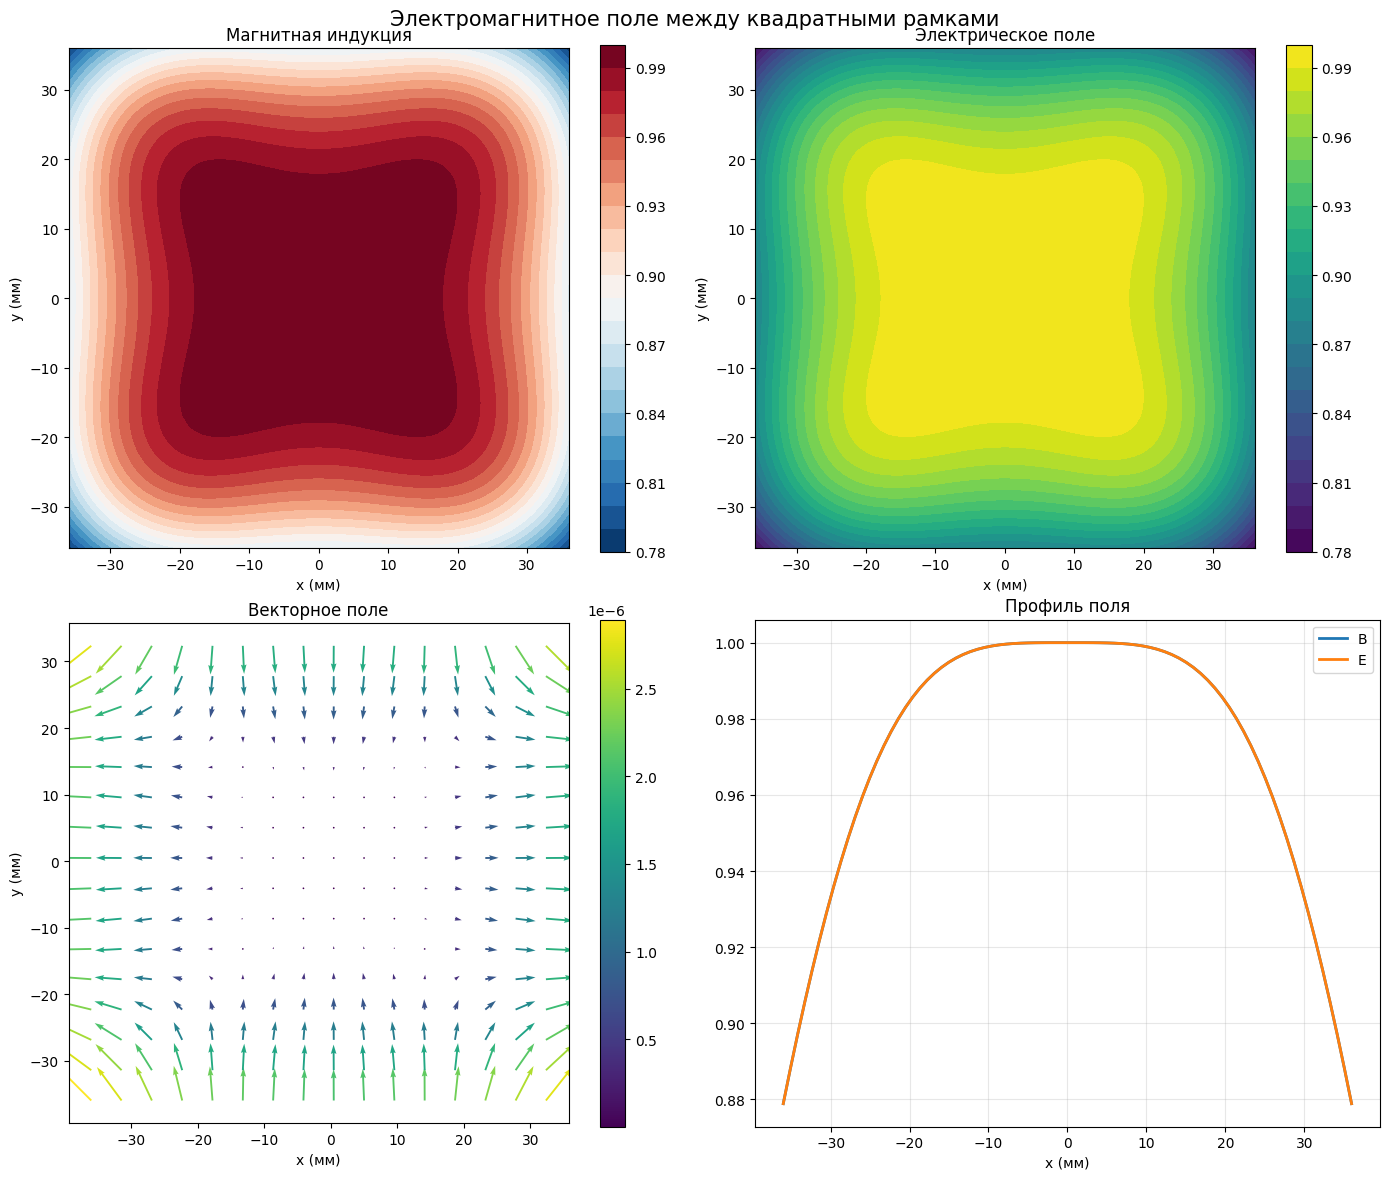

In [2]:

import numpy as np
import matplotlib.pyplot as plt

f = 5e9
c = 3e8
wavelength = c / f

L = wavelength
distance = L / 2

k = 2 * np.pi / wavelength
omega = 2 * np.pi * f

print(f"Частота: {f/1e9:.1f} ГГц")
print(f"Длина волны: {wavelength*1000:.2f} мм")
print(f"Размер рамки: {L*1000:.2f} мм")
print(f"Расстояние между рамками: {distance*1000:.2f} мм")

n_points = 80

x = np.linspace(-L * 0.6, L * 0.6, n_points)
y = np.linspace(-L * 0.6, L * 0.6, n_points)

X, Y = np.meshgrid(x, y)


def magnetic_field_from_wire(
    point_x,
    point_y,
    wire_x1,
    wire_y1,
    wire_x2,
    wire_y2,
    current=1.0,
):
    r1 = np.sqrt(
        (point_x - wire_x1) ** 2
        + (point_y - wire_y1) ** 2
        + distance**2
    )

    r2 = np.sqrt(
        (point_x - wire_x2) ** 2
        + (point_y - wire_y2) ** 2
        + distance**2
    )

    r1 = np.maximum(r1, 1e-9)
    r2 = np.maximum(r2, 1e-9)

    return current / (r1 * r2) * 1e-7


segments = [
    (-L / 2, -L / 2, L / 2, -L / 2),
    (L / 2, -L / 2, L / 2, L / 2),
    (L / 2, L / 2, -L / 2, L / 2),
    (-L / 2, L / 2, -L / 2, -L / 2),
]

B_total = np.zeros_like(X)

for x1, y1, x2, y2 in segments:
    B_total += magnetic_field_from_wire(
        X,
        Y,
        x1,
        y1,
        x2,
        y2,
        current=1.0,
    )

for x1, y1, x2, y2 in segments:
    B_total += magnetic_field_from_wire(
        X,
        Y,
        x1,
        y1,
        x2,
        y2,
        current=0.5,
    )

E_total = np.abs(B_total) * c

B_norm = B_total / np.max(np.abs(B_total))
E_norm = E_total / np.max(np.abs(E_total))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

fig.suptitle(
    "Электромагнитное поле между квадратными рамками",
    fontsize=15,
)

ax = axes[0, 0]

contour1 = ax.contourf(
    X * 1000,
    Y * 1000,
    B_norm,
    levels=25,
    cmap="RdBu_r",
)

plt.colorbar(contour1, ax=ax)

ax.set_title("Магнитная индукция")
ax.set_xlabel("x (мм)")
ax.set_ylabel("y (мм)")
ax.set_aspect("equal")

ax = axes[0, 1]

contour2 = ax.contourf(
    X * 1000,
    Y * 1000,
    E_norm,
    levels=25,
    cmap="viridis",
)

plt.colorbar(contour2, ax=ax)

ax.set_title("Электрическое поле")
ax.set_xlabel("x (мм)")
ax.set_ylabel("y (мм)")
ax.set_aspect("equal")

ax = axes[1, 0]

step = 5

Bx = -np.gradient(B_total, axis=1)[::step, ::step]
By = np.gradient(B_total, axis=0)[::step, ::step]

magnitude = np.sqrt(Bx**2 + By**2)

quiver = ax.quiver(
    X[::step, ::step] * 1000,
    Y[::step, ::step] * 1000,
    Bx,
    By,
    magnitude,
)

plt.colorbar(quiver, ax=ax)

ax.set_title("Векторное поле")
ax.set_xlabel("x (мм)")
ax.set_ylabel("y (мм)")
ax.set_aspect("equal")

ax = axes[1, 1]

center_idx = n_points // 2

ax.plot(
    x * 1000,
    B_norm[center_idx, :],
    linewidth=2,
    label="B",
)

ax.plot(
    x * 1000,
    E_norm[center_idx, :],
    linewidth=2,
    label="E",
)

ax.set_title("Профиль поля")
ax.set_xlabel("x (мм)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "em_field_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
